In [23]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report

In [24]:
TRAIN_DIR = "/content/drive/MyDrive/AIML/FruitinAmazon/train"
TEST_DIR  = "/content/drive/MyDrive/AIML/FruitinAmazon/test"

IMG_HEIGHT   = 128
IMG_WIDTH    = 128
BATCH_SIZE   = 16         # as specified
EPOCHS       = 250        # as specified
VAL_SPLIT    = 0.2
SEED         = 123

  Classes found (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


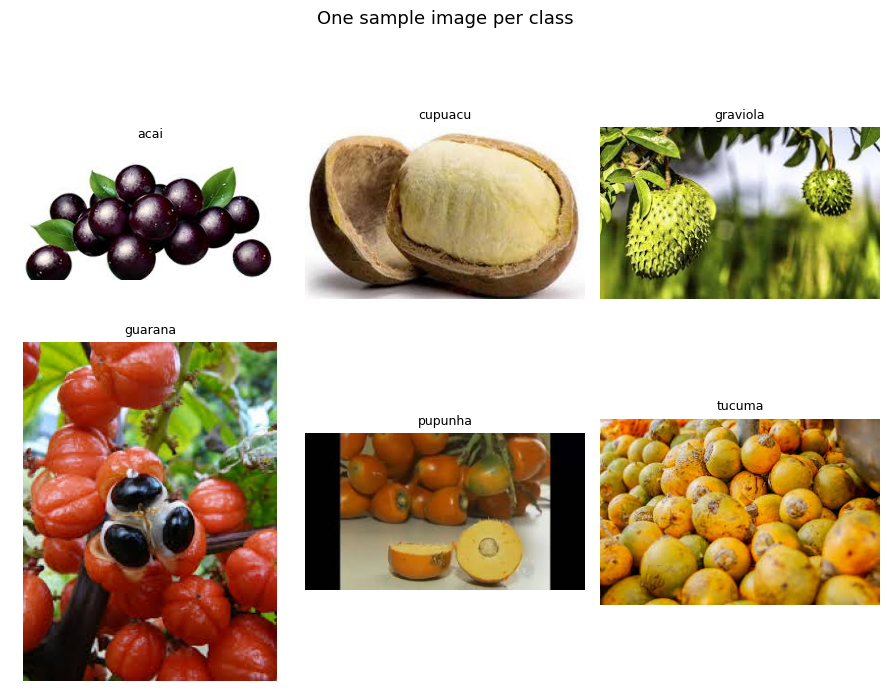

In [25]:
class_names = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])
num_classes = len(class_names)
print(f"  Classes found ({num_classes}): {class_names}")

# one random image per class
sample_images = []
sample_labels = []
for cls in class_names:
    cls_dir  = os.path.join(TRAIN_DIR, cls)
    img_file = random.choice(os.listdir(cls_dir))
    sample_images.append(os.path.join(cls_dir, img_file))
    sample_labels.append(cls)

# Display in a grid with 2 rows
cols = (num_classes + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(cols * 3, 7))
axes = axes.flat

for ax, img_path, label in zip(axes, sample_images, sample_labels):
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(label, fontsize=9)
    ax.axis("off")

# Hide any unused subplot slots
for ax in list(axes)[num_classes:]:
    ax.set_visible(False)

plt.suptitle("One sample image per class", fontsize=13)
plt.tight_layout()
plt.savefig("class_samples.png", dpi=120)
plt.show()

In [26]:
corrupted = []

for cls in class_names:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for img_file in os.listdir(cls_dir):
        image_path = os.path.join(cls_dir, img_file)
        try:
            with Image.open(image_path) as img:
                img.verify()           # detects truncated / corrupt files
        except (IOError, SyntaxError):
            corrupted.append(image_path)
            os.remove(image_path)
            print(f"  Removed corrupted image: {image_path}")

if not corrupted:
    print("  No corrupted images found.")
else:
    print(f"  Total removed: {len(corrupted)}")

  No corrupted images found.


In [27]:
rescale = tf.keras.layers.Rescaling(1.0 / 255)   # normalise [0,255] -> [0,1]

# Training subset (80%)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Validation subset (20%)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Test set (no split, no shuffle)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation="nearest",
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Cache and prefetch for performance
AUTOTUNE  = tf.data.AUTOTUNE
train_ds  = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds    = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds   = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("  Datasets ready.")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.
  Datasets ready.


In [28]:
model = keras.Sequential(
    [
        #input
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="input"),

        # Conv1: 32 filters, 3x3, same padding, stride 1
        layers.Conv2D(32, (3, 3), strides=1, padding="same", name="conv1"),
        layers.Activation("relu", name="relu1"),
        # MaxPool: 2x2, stride 2
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, name="pool1"),

        # Conv2: 32 filters, 3x3, same padding, stride 1
        layers.Conv2D(32, (3, 3), strides=1, padding="same", name="conv2"),
        layers.Activation("relu", name="relu2"),
        # MaxPool: 2x2, stride 2
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, name="pool2"),

        # Fully Connected
        layers.Flatten(name="flatten"),
        layers.Dense(64,  activation="relu", name="hidden_1"),
        layers.Dense(128, activation="relu", name="hidden_2"),

        #output
        layers.Dense(num_classes, activation="softmax", name="output"),
    ],
    name="Fruit_CNN",
)

model.summary()

Model: "Fruit_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",   # labels are plain integers
    metrics=["accuracy"],
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.1003 - loss: 1.9675
Epoch 1: val_loss improved from None to 2.01172, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 369ms/step - accuracy: 0.1111 - loss: 1.9575 - val_accuracy: 0.0556 - val_loss: 2.0117
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.3479 - loss: 1.7070
Epoch 2: val_loss improved from 2.01172 to 1.67691, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 458ms/step - accuracy: 0.3333 - loss: 1.6748 - val_accuracy: 0.1111 - val_loss: 1.6769
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.3549 - loss: 1.4678
Epoch 3: val_loss improved from 1.67691 to 1.46768, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 520ms/step - accuracy: 0.3472 - loss: 1.4306 - val_accuracy: 0.1667 - val_loss: 1.4677
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.6240 - loss: 1.1429
Epoch 4: val_loss improved from 1.46768 to 1.01012, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 389ms/step - accuracy: 0.6250 - loss: 1.0786 - val_accuracy: 0.6111 - val_loss: 1.0101
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.7514 - loss: 0.8735
Epoch 5: val_loss improved from 1.01012 to 0.80214, saving model to best_model.h5


...


Epoch 7: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 302ms/step - accuracy: 0.9444 - loss: 0.2877 - val_accuracy: 0.8333 - val_loss: 0.4690
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.9611 - loss: 0.1998
Epoch 8: val_loss improved from 0.46901 to 0.40330, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 0.9722 - loss: 0.1619 - val_accuracy: 0.8889 - val_loss: 0.4033
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 1.0000 - loss: 0.0723
Epoch 9: val_loss improved from 0.40330 to 0.38645, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 307ms/step - accuracy: 1.0000 - loss: 0.0584 - val_accuracy: 0.8333 - val_loss: 0.3864
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9837 - loss: 0.0583
Epoch 10: val_loss did not improve from 0.38645
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 0.9861 - loss: 0.0497 - val_accuracy: 0.7778 - val_loss: 0.6263
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9712 - loss: 0.0979
Epoch 11: val_loss did not improve from 0.38645
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 443ms/step - accuracy: 0.9861 - loss: 0.0547 - val_accuracy: 0.6111 - val_loss: 1.0683
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9410 - loss: 0.1252
Epoch 12: val_loss did not improve from 0.38645
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 279ms/step - accuracy: 0.9444 - loss: 0.1166 - val_accuracy: 0.7778 - val_loss: 1.2243
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.8812 - loss: 0.3510
Epo


Epoch 17: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.9861 - loss: 0.0739 - val_accuracy: 0.8889 - val_loss: 0.3030
Epoch 18/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 1.0000 - loss: 0.0149
Epoch 18: val_loss improved from 0.30302 to 0.26759, saving model to best_model.h5



Epoch 18: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 314ms/step - accuracy: 1.0000 - loss: 0.0155 - val_accuracy: 0.7778 - val_loss: 0.2676
Epoch 19/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 1.0000 - loss: 0.0139
Epoch 19: val_loss did not improve from 0.26759
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 506ms/step - accuracy: 1.0000 - loss: 0.0148 - val_accuracy: 0.7778 - val_loss: 0.3395
Epoch 20/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 1.0000 - loss: 0.0069
Epoch 20: val_loss did not improve from 0.26759
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 0.8889 - val_loss: 0.3705
Epoch 21/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 1.0000 - loss: 0.0031
Epoch 21: val_loss did not improve from 0.26759
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.8889 - val_loss: 0.3988
Epoch 22/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 1.0000 - loss: 0.0023
Ep

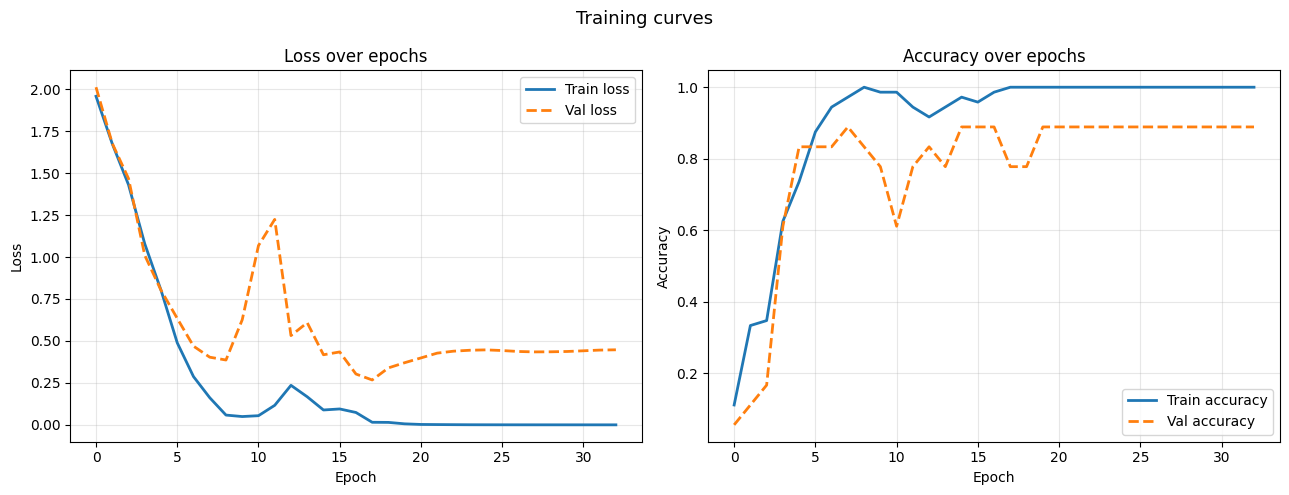

In [30]:
checkpoint_cb = ModelCheckpoint(
    filepath="best_model.h5",
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=15,           # patience for 250-epoch
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1,
)

print(f"\n  Training finished after {len(history.history['loss'])} epochs.")

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(history.history["loss"],     label="Train loss",     linewidth=2)
ax1.plot(history.history["val_loss"], label="Val loss",       linewidth=2, linestyle="--")
ax1.set_title("Loss over epochs");  ax1.set_xlabel("Epoch");  ax1.set_ylabel("Loss")
ax1.legend();  ax1.grid(True, alpha=0.3)

ax2.plot(history.history["accuracy"],     label="Train accuracy", linewidth=2)
ax2.plot(history.history["val_accuracy"], label="Val accuracy",   linewidth=2, linestyle="--")
ax2.set_title("Accuracy over epochs");  ax2.set_xlabel("Epoch");  ax2.set_ylabel("Accuracy")
ax2.legend();  ax2.grid(True, alpha=0.3)

plt.suptitle("Training curves", fontsize=13)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()

In [31]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\n  Test loss     : {test_loss:.4f}")
print(f"  Test accuracy : {test_acc * 100:.2f}%")


  Test loss     : 0.6475
  Test accuracy : 73.33%


In [32]:
model.save("fruit_cnn_final.h5")
print("  Model saved")

loaded_model = keras.models.load_model("fruit_cnn_final.h5")
print("  Model loaded successfully.")

r_loss, r_acc = loaded_model.evaluate(test_ds, verbose=0)
print(f"\n  Loaded model — test loss: {r_loss:.4f}  |  test accuracy: {r_acc * 100:.2f}%")

  Model saved


  Model loaded successfully.

  Loaded model — test loss: 0.6475  |  test accuracy: 73.33%



Classification Report:
              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       0.56      1.00      0.71         5
    graviola       1.00      0.80      0.89         5
     guarana       0.71      1.00      0.83         5
     pupunha       0.75      0.60      0.67         5
      tucuma       1.00      0.20      0.33         5

    accuracy                           0.73        30
   macro avg       0.80      0.73      0.71        30
weighted avg       0.80      0.73      0.71        30



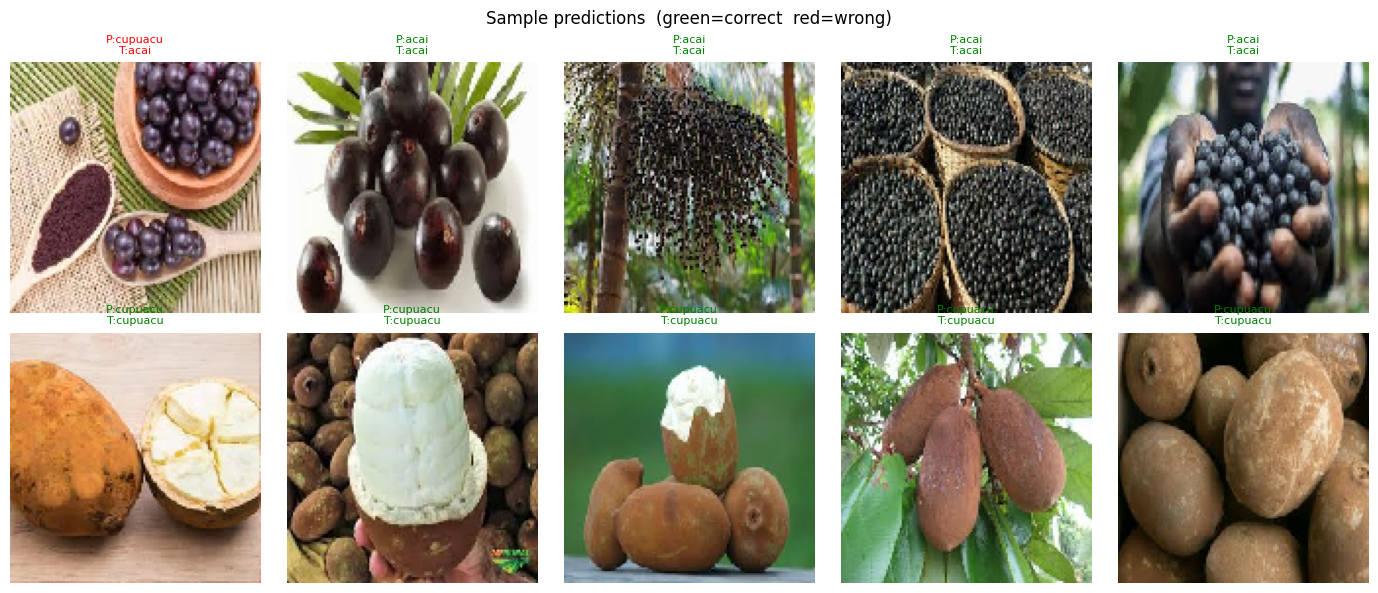

In [33]:
# Collect true labels and predicted probabilities from the test set
y_true = []
y_prob = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_prob.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = np.argmax(y_prob, axis=1)   # highest-probability class per sample

# Classification report (precision, recall, F1 per class)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 10 sample predictions
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
test_images_list = []
test_labels_list = []
for images, labels in test_ds.unbatch().take(10):
    test_images_list.append(images.numpy())
    test_labels_list.append(labels.numpy())

for ax, img, true_lbl in zip(axes.flat, test_images_list, test_labels_list):
    ax.imshow(img)
    pred_idx  = np.argmax(loaded_model.predict(img[np.newaxis], verbose=0))
    pred_name = class_names[pred_idx]
    true_name = class_names[true_lbl]
    color     = "green" if pred_idx == true_lbl else "red"
    ax.set_title(f"P:{pred_name}\nT:{true_name}", fontsize=8, color=color)
    ax.axis("off")

plt.suptitle("Sample predictions  (green=correct  red=wrong)", fontsize=12)
plt.tight_layout()
plt.savefig("predictions.png", dpi=120)
plt.show()